In [1]:
from pathlib import Path
import sys
import math

planning_path = Path('.').absolute().parents[0] / 'cloud_auto_park'
print(planning_path)

sys.path.append(str(planning_path))

from trajectory_utils import *
import numpy as np
import time


/project/project/sim_ws/src/digital_twin/cloud_auto_park/cloud_auto_park


In [2]:
def setup_planning_scenario(gap_dist, x_sep, y_sep, is_left, is_wall):
    
    obstacle_sep = gap_dist
    sign = 1 if is_left else -1
    obb_1 = OrientedBoundingBox(-x_sep, sign * y_sep, 4.0, 2.0, math.pi/2)
    obb_2 = OrientedBoundingBox(-x_sep - obstacle_sep, sign * y_sep, 4.0, 2.0, math.pi/2)
    wall = OrientedBoundingBox(-5.0, -sign * 2.5, 12.0, 1.0, 0.0)
    
    obstacles = [obb_1, obb_2]
    if is_wall: obstacles.append(wall)
    
    desired_pose = OrientedBoundingBox(-x_sep - (obstacle_sep / 2.0), sign * y_sep, 4.0, 2.0, -sign * math.pi/2)
    
    return desired_pose, obstacles


In [3]:
fig_save_path = 'figures/doe/'

def run_metrics(traj, obstacles):
    
    # thresholds
    cf=3.30; cr=3.80; m=2.62; lf=0.15875; lr=0.17145; iz=0.062; vx=1; delta_max = 0.3
    K_max = delta_max / ((lf + lr) + (m / (lf + lr))*(lr/(cf) - lf/(cr))*(vx)*(vx))
    D_min = 0.25
    
    min_separation = math.inf
    # for each obstacle, get closest distance between ego following trajectory and the obstacle
    for idx, obstacle_obb in enumerate(obstacles):
        separation = get_min_separation_between_traj_and_obs(traj, obstacle_obb)
        if separation < min_separation:
            min_separation = separation
        
    max_abs_curv = np.max(np.abs(traj.curvatures))
    
    # feasibility checks
    feas = (min_separation > D_min) and (max_abs_curv <= K_max)
    pseudofeas = (min_separation > 0) and (max_abs_curv <= K_max)
    
    return {'min_separation': min_separation, 'max_abs_curv': max_abs_curv, 'feas': feas, 'pseudofeas': pseudofeas}

def run_planning_scenario(desired_pose, obstacles, metadata):
    
    def get_feas_string(feas, pseudofeas):
        if feas: return 'Feasible'
        elif pseudofeas: return 'Pseudo-Feasible'
        else: return 'Infeasible'
    
    metrics = {}
    
    # run optimizer to get trajectory
    traj_optimizer = TrajectoryOptimizer(method='BFGS', speed_mps=1.0, sample_rate_hz=50, reverse=True)
    
    # profile traj generation time
    start_time = time.process_time()
    traj_optimizer.generate_optimal_trajectory(desired_pose, obstacles)
    elapsed_time = time.process_time() - start_time
    metrics['solve_time'] = elapsed_time
    metrics['traj'] = traj_optimizer.optimized_traj
    
    # construct filename from metadata
    dir_string = 'left' if metadata['is_left'] else 'right'
    wall_string = 'wall' if metadata['is_wall'] else 'nowall'
    filename_prefix = f"planner_gap_{metadata['gap_dist']:.2f}_xsep_{metadata['x_sep']:.2f}_ysep_{metadata['y_sep']:.2f}_{dir_string}_{wall_string}"
    filename_prefix = filename_prefix.replace('.', '-')
    
    # construct figure title/subtitle from metadata
    dir_string = 'Left' if metadata['is_left'] else 'Right'
    wall_string = 'with Wall' if metadata['is_wall'] else 'without Wall'
    title_string = f'Planning DOE - {dir_string} Park {wall_string}'
    subtitle_string = f"$d_{{gap}} = {(metadata['gap_dist'] - 2):.2f}$m, $d_x = {(metadata['x_sep']):.2f}$m, $d_y = {(metadata['y_sep']):.2f}$m"
    
    # get metrics, plot and save initial trajectory
    metrics['initial'] = run_metrics(traj_optimizer.initial_traj, obstacles)
    feas, pseudofeas = metrics['initial']['feas'], metrics['initial']['pseudofeas']
    fig, ax = plot_desired_path(traj_optimizer.initial_traj, obstacles, num_intermediate_ego=50)
    fig.suptitle(title_string + f' (Initial) - {get_feas_string(feas, pseudofeas)}')
    ax.set_title(subtitle_string, fontsize=10)
    fig.savefig(fig_save_path + filename_prefix + f'_init_{get_feas_string(feas, pseudofeas)}.svg')
    
    # get metrics, plot and save final trajectory
    metrics['final'] = run_metrics(traj_optimizer.optimized_traj, obstacles)
    feas, pseudofeas = metrics['final']['feas'], metrics['final']['pseudofeas']
    fig, ax = plot_desired_path(traj_optimizer.optimized_traj, obstacles, num_intermediate_ego=50)
    fig.suptitle(title_string  + f' (Optimized) - {get_feas_string(feas, pseudofeas)}')
    ax.set_title(subtitle_string, fontsize=10) 
    fig.savefig(fig_save_path + filename_prefix + f'_opt_{get_feas_string(feas, pseudofeas)}.svg')
    
    return metrics

def construct_and_run_scenario(metadata):
    
    desired_pose, obstacles = setup_planning_scenario(**metadata)
    metrics = run_planning_scenario(desired_pose, obstacles, metadata)
    return metrics


In [4]:
import itertools

gap_dists = [4.5, 5.0, 5.5, 6.0, 6.5, 7.0]
x_seps = [1.0, 2.0, 3.0, 4.0]
y_seps = [3.5, 4.0, 4.5, 5.0]
walls = [True, False]
directions = [True, False]
combinations = list(itertools.product(gap_dists, x_seps, y_seps, walls, directions))
print(len(combinations))

# setup all combinations for doe
scenarios = []
for combo in combinations:
    metadata = {
        'gap_dist': combo[0], 
        'x_sep': combo[1], 
        'y_sep': combo[2], 
        'is_left': combo[3], 
        'is_wall': combo[4]    
    }
    scenarios.append(metadata)

all_desired_poses = []
all_obstacles = []
for scenario in scenarios:
    desired_pose, obstacles = setup_planning_scenario(**scenario)
    all_desired_poses.append(desired_pose)
    all_obstacles.append(obstacles)


384


In [5]:
import multiprocessing as mp

results = {}

# Determine your system's core count
cores = mp.cpu_count()

with mp.Pool(processes=cores) as pool:
    results = pool.map(construct_and_run_scenario, scenarios)


/project/project/sim_ws/src/digital_twin/cloud_auto_park/cloud_auto_park/trajectory_utils.py:275: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, ax = plt.subplots(1)
/project/project/sim_ws/src/digital_twin/cloud_auto_park/cloud_auto_park/trajectory_utils.py:275: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, ax = plt.subplots(1)
/project/project/sim_ws/src/digital_twin/cloud_auto_park/cloud_auto_park/trajectory_utils.py:275: RuntimeWarning: More tha

In [6]:
import pandas as pd

gap_dists = []
x_seps = []
y_seps = []
walls = []
directions = []
optimized = []
solve_times = []
min_sep = []
max_abs_curv = []
trajs = []

for i in range(len(results)):
    gap_dists.append(scenarios[i]['gap_dist'])
    gap_dists.append(scenarios[i]['gap_dist'])
    x_seps.append(scenarios[i]['x_sep'])
    x_seps.append(scenarios[i]['x_sep'])
    y_seps.append(scenarios[i]['y_sep'])
    y_seps.append(scenarios[i]['y_sep'])
    walls.append(scenarios[i]['is_wall'])
    walls.append(scenarios[i]['is_wall'])
    directions.append(scenarios[i]['is_left'])
    directions.append(scenarios[i]['is_left'])
    optimized.append(False)
    optimized.append(True)
    solve_times.append(None)
    solve_times.append(results[i]['solve_time'])
    min_sep.append(results[i]['initial']['min_separation'])
    min_sep.append(results[i]['final']['min_separation'])
    max_abs_curv.append(results[i]['initial']['max_abs_curv'])
    max_abs_curv.append(results[i]['final']['max_abs_curv'])
    trajs.append(results[i]['traj'])

results_df = pd.DataFrame(
    dict(zip(
        ['gap_dist', 'x_sep', 'y_sep', 'is_wall', 'is_left', 'is_optimized', 'solve_time', 'min_sep', 'max_abs_curv'],
        [gap_dists, x_seps, y_seps, walls, directions, optimized, solve_times, min_sep, max_abs_curv]
    ))
)


In [7]:
import pickle

# save dataframe for future analysis
with open(f'data/results.pkl', 'wb') as f:
    pickle.dump(results_df, f)

# save trajectories for future analysis
with open(f'data/trajectories.pkl', 'wb') as f:
    pickle.dump(trajs, f)

# save obstacles for future analysis
with open(f'data/obstacles.pkl', 'wb') as f:
    pickle.dump(all_obstacles, f)

# save desired poses for future analysis
with open(f'data/desired_poses.pkl', 'wb') as f:
    pickle.dump(all_desired_poses, f)


In [8]:

# data processing
gaps = [4.5, 5.0, 5.5, 6.0, 6.5, 7.0]
data_groups = []

# thresholds
cf=3.30; cr=3.80; m=2.62; lf=0.15875; lr=0.17145; iz=0.062; vx=1; delta_max = 0.3
K_max = delta_max / ((lf + lr) + (m / (lf + lr))*(lr/(cf) - lf/(cr))*(vx)*(vx))
D_min = 0.25

# params
CAR_WIDTH = 2
CAR_LENGTH = 4

# determine feasibile/pseudo-feasible trajectories
results_df['feas'] = (results_df['min_sep'] > D_min) & (results_df['max_abs_curv'] <= K_max)
results_df['psuedo_feas'] = (results_df['min_sep'] > 0) & (results_df['max_abs_curv'] <= K_max)

results_df_opt = results_df[results_df['is_optimized']]

for gap in gaps:
    gap_data = results_df[(results_df['gap_dist'] == gap) & (results_df['is_optimized'])]
    data_groups.append(gap_data)


In [9]:
results_df_opt


,gap_dist,x_sep,y_sep,is_wall,is_left,is_optimized,solve_time,min_sep,max_abs_curv,feas,psuedo_feas
1,4.5,1.0,3.5,True,True,True,7.052522,-0.259737,0.515379,False,False
3,4.5,1.0,3.5,False,True,True,3.223034,-0.079642,1.647575,False,False
5,4.5,1.0,3.5,True,False,True,9.424213,-0.259738,0.515380,False,False
7,4.5,1.0,3.5,False,False,True,4.221993,-0.080210,1.647028,False,False
9,4.5,1.0,4.0,True,True,True,9.615148,-0.140340,0.421263,False,False
...,...,...,...,...,...,...,...,...,...,...,...
759,7.0,4.0,4.5,False,False,True,3.949882,1.137685,0.395735,True,True
761,7.0,4.0,5.0,True,True,True,11.791073,0.901744,0.503447,True,True
763,7.0,4.0,5.0,False,True,True,12.217474,1.144094,0.391707,True,True
765,7.0,4.0,5.0,True,False,True,11.392324,0.907685,0.514799,True,True


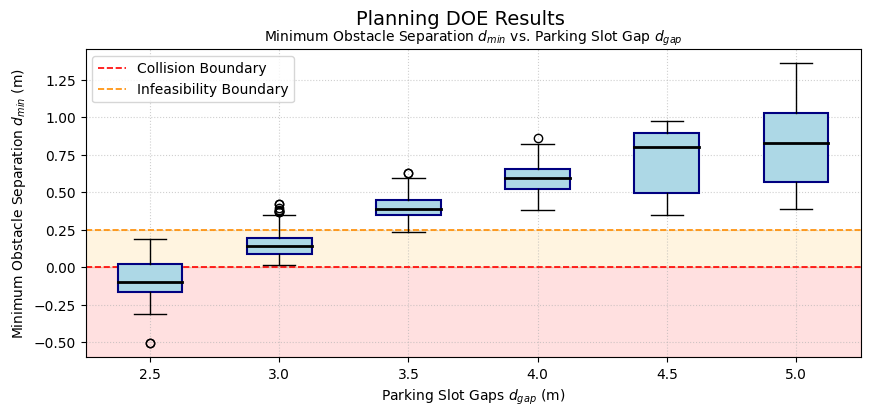

In [10]:
plt.gcf().set_size_inches(10, 4)

plt.axhline(y=0, color='red', linestyle='--', linewidth=1.2, label='Collision Boundary')
plt.axhline(y=D_min, color='darkorange', linestyle='--', linewidth=1.2, label='Infeasibility Boundary')

plt.boxplot([group['min_sep'] for group in data_groups], labels=[g - CAR_WIDTH for g in gaps],
            patch_artist=True,
            medianprops={'color': 'black', 'linewidth': 2},
            boxprops=dict(facecolor='lightblue', color='navy', linewidth=1.5))

ymin, ymax = plt.ylim()

plt.axhspan(ymin=ymin, ymax=0, color='red', alpha=0.12, zorder=-999)
plt.axhspan(ymin=0, ymax=D_min, color='orange', alpha=0.12, zorder=-998)

plt.ylim(ymin, ymax)

plt.grid(True, linestyle=':', alpha=0.6)
plt.xlabel('Parking Slot Gaps $d_{gap}$ (m)')
plt.ylabel('Minimum Obstacle Separation $d_{min}$ (m)')
plt.legend(loc='upper left')
plt.suptitle('Planning DOE Results', fontsize=14)
plt.gca().set_title('Minimum Obstacle Separation $d_{min}$ vs. Parking Slot Gap $d_{gap}$', fontsize=10)
plt.savefig('figures/planning_doe_minsep_boxplot.svg')


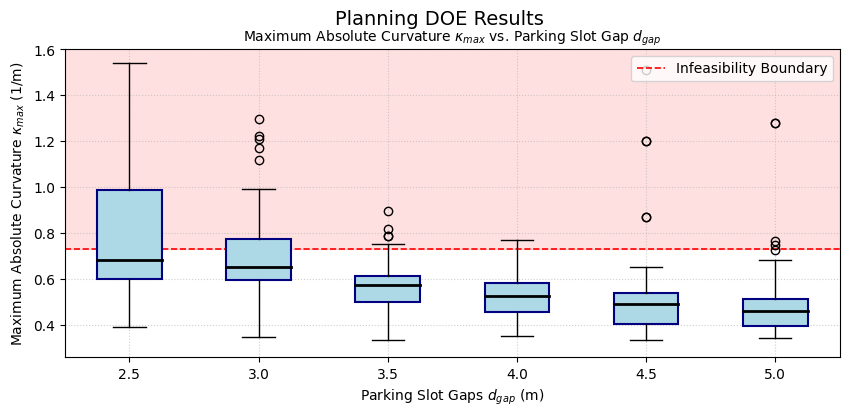

In [19]:
plt.gcf().set_size_inches(10, 4)

plt.axhline(y=K_max, color='red', linestyle='--', linewidth=1.2, label='Infeasibility Boundary')

plt.boxplot([group['max_abs_curv'] for group in data_groups], labels=[g - 2 for g in gaps],
            patch_artist=True,
            medianprops={'color': 'black', 'linewidth': 2},
            boxprops=dict(facecolor='lightblue', color='navy', linewidth=1.5))

ymin, ymax = plt.ylim()

plt.axhspan(ymin=K_max, ymax=10, color='red', alpha=0.12, zorder=-999)

plt.ylim(ymin, 1.6)

plt.grid(True, linestyle=':', alpha=0.6)
plt.xlabel('Parking Slot Gaps $d_{gap}$ (m)')
plt.ylabel('Maximum Absolute Curvature $\kappa_{max}$ (1/m)')
plt.legend(loc='upper right')
plt.suptitle('Planning DOE Results', fontsize=14)
plt.gca().set_title('Maximum Absolute Curvature $\kappa_{max}$ vs. Parking Slot Gap $d_{gap}$', fontsize=10)
plt.savefig('figures/planning_doe_maxabscurv_boxplot.svg')


In [12]:
all_groups = [results_df_opt] + data_groups
all_gaps = [0] + gaps

for idx, group in enumerate(all_groups):
    print('=============')
    print(f"(gap = {all_gaps[idx]:.2f}) mean min gap = {np.mean(group['min_sep']):.5f}")
    print(f"(gap = {all_gaps[idx]:.2f}) mean max abs curv = {np.mean(group['max_abs_curv']):.5f}")
    print(f"(gap = {all_gaps[idx]:.2f}) pseudofeas percentage = {np.mean(group['psuedo_feas'] * 100):.5f}")
    print(f"(gap = {all_gaps[idx]:.2f}) feas percentage = {np.mean(group['feas'] * 100):.5f}")
    print(f"(gap = {all_gaps[idx]:.2f}) mean solve time = {np.mean(group['solve_time']):.5f}")


(gap = 0.00) mean min gap = 0.43287
(gap = 0.00) mean max abs curv = 0.59998
(gap = 0.00) pseudofeas percentage = 73.17708
(gap = 0.00) feas percentage = 61.45833
(gap = 0.00) mean solve time = 9.44832
(gap = 4.50) mean min gap = -0.08170
(gap = 4.50) mean max abs curv = 0.80853
(gap = 4.50) pseudofeas percentage = 3.12500
(gap = 4.50) feas percentage = 0.00000
(gap = 4.50) mean solve time = 8.79744
(gap = 5.00) mean min gap = 0.16492
(gap = 5.00) mean max abs curv = 0.68824
(gap = 5.00) pseudofeas percentage = 67.18750
(gap = 5.00) feas percentage = 1.56250
(gap = 5.00) mean solve time = 8.72338
(gap = 5.50) mean min gap = 0.39287
(gap = 5.50) mean max abs curv = 0.56747
(gap = 5.50) pseudofeas percentage = 87.50000
(gap = 5.50) feas percentage = 85.93750
(gap = 5.50) mean solve time = 8.92521
(gap = 6.00) mean min gap = 0.58367
(gap = 6.00) mean max abs curv = 0.52133
(gap = 6.00) pseudofeas percentage = 95.31250
(gap = 6.00) feas percentage = 95.31250
(gap = 6.00) mean solve time = 

In [15]:
all_groups[1][all_groups[1]['psuedo_feas']]


,gap_dist,x_sep,y_sep,is_wall,is_left,is_optimized,solve_time,min_sep,max_abs_curv,feas,psuedo_feas
27,4.5,1.0,5.0,False,True,True,10.232371,0.106035,0.705872,False,True
31,4.5,1.0,5.0,False,False,True,7.152412,0.106200,0.706005,False,True
